# 17. Results (reproducible analysis)

Every number and figure in the Results section, computed from the real screen output
(`results/lr_panel_results*.parquet`, `results/controls/*.parquet`). Mirrors `Final_Writeup/RESULTS_SKELETON.md`
and the three aims. Run top to bottom with the **cosmx-pointpattern** kernel (repo `.venv`).

**Figure style (write-up):** white background, IBM colourblind-safe palette, Arial, no baked titles (described in
the LaTeX caption), panel labels A/B/C for composites. Strips: control = blue `#648FFF`, infected = magenta
`#DC267F`, control = purple `#785EF0`. Figures save to `results/figures/pub_*.png` and display inline.

## Setup: style, load the screen, define SES, groups, gene classes

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

ROOT = Path.cwd()
while not (ROOT / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FIG = ROOT / "results" / "figures"

# --- publication style: white, IBM colourblind-safe, Arial ---
plt.rcParams.update({"font.family": "Arial", "figure.facecolor": "white", "axes.facecolor": "white",
                     "savefig.facecolor": "white", "axes.linewidth": 0.8, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})
IBM = {"blue": "#648FFF", "purple": "#785EF0", "magenta": "#DC267F", "orange": "#FE6100", "yellow": "#FFB000"}
STRIP = {"strip_1": IBM["blue"], "strip_2": IBM["magenta"], "strip_3": IBM["purple"]}
STRIP_LABEL = {"strip_1": "Strip 1 (control)", "strip_2": "Strip 2 (infected)", "strip_3": "Strip 3 (control)"}
POS, NEG = IBM["orange"], IBM["blue"]   # diverging convention: orange = positive/high, blue = negative/low
INK, MUTED, BAND = "0.15", "0.45", "0.90"
MPP = 0.12028   # CosMx SMI nominal pixel size (um/px). The data carries NO physical calibration
                # (points live in an uncalibrated "unit"/pixel frame); this is the instrument nominal only.
R_CC = 50       # px: design cutoff of the two-part radius grid (dense <=50 px, coarse above); see Methods
def panel(ax, letter):  # composite panel label
    ax.text(-0.02, 1.04, letter, transform=ax.transAxes, fontsize=13, fontweight="bold", va="bottom", ha="right")

R = np.load(ROOT / "results" / "lr_panel_results.parquet.r_vals.npy")
v1 = pd.read_parquet(ROOT / "results" / "lr_panel_results.parquet")
v2 = pd.read_parquet(ROOT / "results" / "lr_panel_results_v2.parquet")
d = pd.concat([v1, v2], ignore_index=True)

def ses_curve(row):
    lo, hi, ob = np.array(row.l_lo, float), np.array(row.l_hi, float), np.array(row.l_obs, float)
    H = np.where((hi - lo) / 2 == 0, np.nan, (hi - lo) / 2)
    return (ob - (hi + lo) / 2) / H
def peak_ses(row): return np.nanmax(ses_curve(row))
def n_exceed(row):
    e = np.array(row.l_obs, float) > np.array(row.l_hi, float)
    best = cur = 0
    for x in e:
        cur = cur + 1 if x else 0; best = max(best, cur)
    return int(best), int(e.sum())

d["peak"] = d.apply(peak_ses, axis=1)
d["r_at_peak"] = [R[np.nanargmax(ses_curve(r))] for _, r in d.iterrows()]
d["max_consec"] = [n_exceed(r)[0] for _, r in d.iterrows()]
d["pair"] = d.ligand + " x " + d.receptor

GROUPS = {
 "G1_cytokeratin": [("KRT8","KRT18"),("KRT5","KRT14"),("KRT5","KRT15"),("KRT8","KRT19"),("KRT18","KRT19"),("KRT14","KRT15"),("KRT5","KRT17"),("KRT14","KRT17"),("KRT19","EPCAM"),("KRT8","EPCAM")],
 "G3_epi_niche":   [("KRT8","SCGB1A1"),("KRT18","SCGB1A1"),("KRT8","MUC5B"),("KRT18","MUC5AC"),("KRT19","SCGB3A1"),("EPCAM","MUC5B"),("EPCAM","SCGB3A1"),("EPCAM","FOXJ1")],
 "G4_immune":      [("CD3D","CD3E"),("CD3D","CD4"),("CD3D","CD8A"),("CD8A","CD8B"),("CD4","FOXP3"),("CD68","CD163"),("CD68","CD14"),("CD19","MS4A1"),("ITGAX","HLA-DRA"),("NCAM1","NKG7")],
 "G5_stromal":     [("COL1A1","COL3A1"),("COL1A1","COL1A2"),("ACTA2","TAGLN"),("ACTA2","MYH11"),("PECAM1","VWF"),("PECAM1","CDH5"),("VWF","CDH5"),("DCN","LUM")],
 "G6_neg_anchor":  [("MALAT1","KRT18"),("MALAT1","CD3D"),("MALAT1","COL1A1"),("KRT8","CD3D"),("KRT8","COL1A1"),("KRT8","PECAM1"),("CD3D","COL1A1"),("MUC5AC","CD68"),("SFTPC","ACTA2"),("SFTPC","COL1A1")],
 "G7_infection":   [("ISG15","IFIT1"),("IFIT1","IFIT3"),("ISG15","MX1"),("OAS1","ISG15"),("ISG15","KRT8"),("IFIT1","KRT18"),("MX1","KRT5"),("CXCL10","CXCL11"),("CXCL8","IL6"),("IL6","IL1B"),("TNF","IL1B"),("ISG15","CD68"),("CXCL10","CD3D"),("HLA-DRA","CD3D"),("HLA-DRA","CD68")],
 "G8_paracrine":   [("TGFB1","TGFBR2"),("CXCL12","CXCR4"),("CCL2","CCR2"),("CCL5","CCR5"),("IL1B","IL1R1"),("TNF","TNFRSF1A"),("WNT5A","FZD2"),("FGF7","FGFR2"),("HGF","MET"),("EGF","EGFR")],
}
g2k = {frozenset(p): g for g, prs in GROUPS.items() for p in prs}
d["grp"] = [g2k.get(frozenset((a, b)), "G0_cellchatdb") for a, b in zip(d.ligand, d.receptor)]

def gclass(g):
    g = str(g)
    if g.startswith(("CXCL","CCL","CXCR","CCR","ACKR")): return "chemokine"
    if g.startswith(("OAS","ISG","IFIT","MX")): return "interferon"
    if g.startswith(("TNF","IL")): return "cytokine/TNF"
    if g.startswith("FGF"): return "FGF/growth"
    if g.startswith(("COL","FN1","VIM","THBS","LAMA")): return "stromal/ECM"
    if g.startswith(("KRT","SCGB","EPCAM","MUC")): return "epithelial"
    if g.startswith(("CD","PDCD","HLA","B2M","ICOS")): return "immune"
    return "other"

print("rows:", len(d), "| unique (pair,strip):", d[["pair","strip"]].drop_duplicates().shape[0],
      "| failures:", (d.status != "ok").sum())

rows: 614 | unique (pair,strip): 605 | failures: 0


## R1: Screen scale and control calibration  (Aim 1)
Controls on one comparable SES axis (envelope = grey band): Positive control near the midline, both negatives
below the lower edge in every strip.

Peak SES by strip:
  KRT8 x KRT18    (Positive control): [0.2, 0.23, 0.16]
  KRT8 x SCGB3A1  (Negative control): [-3.63, -2.41, -1.59]
  MALAT1 x KRT18    (Negative control): [-2.03, -2.69, -1.54]


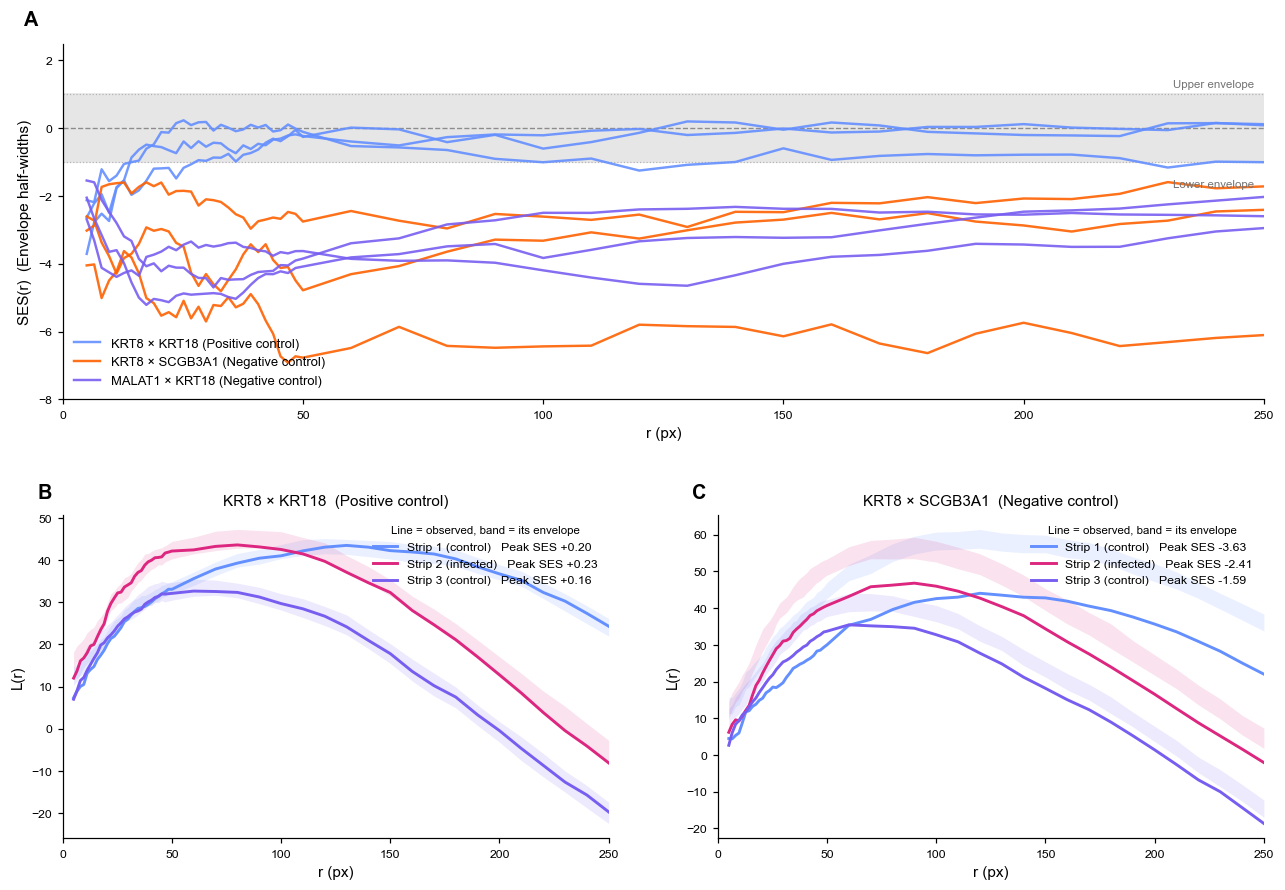

In [2]:
def get_row(a, b, st):
    r = d[(d.ligand == a) & (d.receptor == b) & (d.strip == st)]
    return r.iloc[0] if len(r) else None
def ctrl_row(a, b, st):
    if a == "KRT8" and b == "SCGB3A1":
        return pd.read_parquet(ROOT / "results" / "controls" / f"KRT8_SCGB3A1_{st}.parquet").iloc[0]
    return get_row(a, b, st)

controls = [("KRT8","KRT18","Positive control",IBM["blue"]),("KRT8","SCGB3A1","Negative control",IBM["orange"]),("MALAT1","KRT18","Negative control",IBM["purple"])]
print("Peak SES by strip:")
for a, b, lab, _ in controls:
    ps = [round(float(peak_ses(ctrl_row(a, b, st))), 2) for st in ["strip_1","strip_2","strip_3"]]
    print(f"  {a} x {b:8} ({lab}): {ps}")

from matplotlib.gridspec import GridSpec
SLAB = {"strip_1": "Strip 1 (control)", "strip_2": "Strip 2 (infected)", "strip_3": "Strip 3 (control)"}
fig = plt.figure(figsize=(12, 8.4))
gs = GridSpec(2, 2, height_ratios=[1.1, 1.0], hspace=0.34, wspace=0.2, left=0.07, right=0.98, top=0.95, bottom=0.09)
axA = fig.add_subplot(gs[0, :])
axA.axhspan(-1, 1, color=BAND, zorder=0)
axA.axhline(0, color="0.55", ls="--", lw=0.9); axA.axhline(1, color="0.7", ls=":", lw=0.8); axA.axhline(-1, color="0.7", ls=":", lw=0.8)
for a, b, lab, col in controls:
    for i, st in enumerate(["strip_1","strip_2","strip_3"]):
        axA.plot(R, ses_curve(ctrl_row(a, b, st)), color=col, lw=1.6, alpha=0.9, label=f"{a} × {b} ({lab})" if i == 0 else None)
axA.set_xlabel("r (px)", fontsize=10); axA.set_ylabel("SES(r)  (Envelope half-widths)", fontsize=10)
axA.set_ylim(-8, 2.5); axA.set_xlim(0, 250); axA.tick_params(labelsize=8)
axA.text(248, 1.2, "Upper envelope", fontsize=7.5, ha="right", color=MUTED); axA.text(248, -1.75, "Lower envelope", fontsize=7.5, ha="right", color=MUTED)
axA.legend(frameon=False, fontsize=8.5, loc="lower left"); panel(axA, "A")
for (a, b, lab), gcol, L in [(("KRT8","KRT18","Positive control"), gs[1,0], "B"), (("KRT8","SCGB3A1","Negative control"), gs[1,1], "C")]:
    ax = fig.add_subplot(gcol)
    for st in ["strip_1","strip_2","strip_3"]:
        row = ctrl_row(a, b, st)
        lo, hi, ob = np.array(row.l_lo,float), np.array(row.l_hi,float), np.array(row.l_obs,float)
        ax.fill_between(R, lo, hi, color=STRIP[st], alpha=0.13, lw=0)
        ax.plot(R, ob, color=STRIP[st], lw=1.9, label=f"{SLAB[st]}   Peak SES {peak_ses(row):+.2f}")
    ax.set_title(f"{a} × {b}  ({lab})", fontsize=10)
    ax.set_xlabel("r (px)", fontsize=10); ax.set_ylabel("L(r)", fontsize=10)
    ax.set_xlim(0, 250); ax.tick_params(labelsize=8)
    ax.legend(frameon=False, fontsize=8, loc="upper right", title="Line = observed, band = its envelope", title_fontsize=7.5); panel(ax, L)
fig.savefig(FIG / "pub_r1_controls.png", dpi=300, bbox_inches="tight"); plt.show()

## R2: Group-wise co-localisation  (Aim 1)
Focal signalling groups sit positive; diffuse/cross-compartment groups null-to-negative; the epithelial-niche
group is strongly negative (spatial avoidance).

                size  mean  median
grp                               
G8_paracrine      35  0.39    0.50
G7_infection      41  0.35    0.35
G5_stromal        22  0.31    0.29
G4_immune         30  0.30    0.29
G0_cellchatdb    429  0.27    0.28
G6_neg_anchor     21 -0.16    0.08
G1_cytokeratin    30 -0.19    0.01
G3_epi_niche       6 -1.98   -1.42

per-strip mean Peak SES:
strip           strip_1  strip_2  strip_3
grp                                      
G8_paracrine       0.04     0.51     0.64
G7_infection       0.35     0.36     0.35
G5_stromal         0.17     0.25     0.51
G4_immune          0.29     0.45     0.16
G0_cellchatdb      0.18     0.30     0.33
G6_neg_anchor     -0.28    -0.30     0.11
G1_cytokeratin    -0.60     0.02     0.01
G3_epi_niche      -2.86    -2.09    -1.00


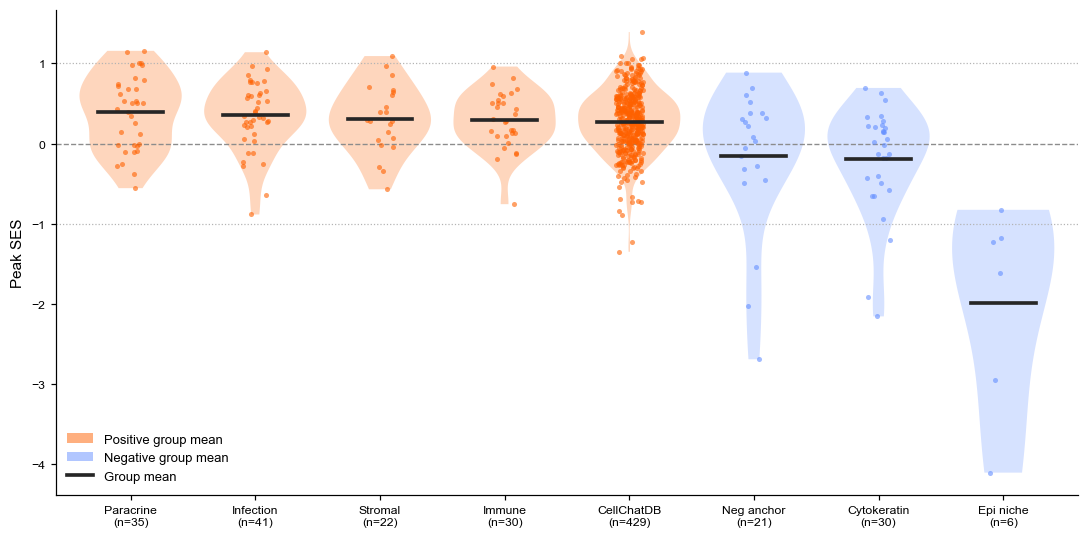

In [3]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
order = ["G8_paracrine","G7_infection","G5_stromal","G4_immune","G0_cellchatdb","G6_neg_anchor","G1_cytokeratin","G3_epi_niche"]
label = {"G8_paracrine":"Paracrine","G7_infection":"Infection","G5_stromal":"Stromal","G4_immune":"Immune","G0_cellchatdb":"CellChatDB","G6_neg_anchor":"Neg anchor","G1_cytokeratin":"Cytokeratin","G3_epi_niche":"Epi niche"}
gm = d.groupby("grp").peak.agg(["size","mean","median"]).reindex(order).round(2)
print(gm.to_string())
print("\nper-strip mean Peak SES:")
print(d.pivot_table("peak","grp","strip","mean").reindex(order).round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5.0))
rng = np.random.default_rng(0)
data = [d[d.grp == g].peak.values for g in order]
means = [float(np.nanmean(x)) for x in data]
parts = ax.violinplot(data, positions=range(len(order)), widths=0.82, showextrema=False)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(POS if means[i] > 0 else NEG); pc.set_alpha(0.26); pc.set_edgecolor("none")
for i, x in enumerate(data):
    ax.scatter(i + rng.uniform(-0.11, 0.11, len(x)), x, s=11, c=(POS if means[i] > 0 else NEG), alpha=0.6, lw=0, zorder=3)
    ax.plot([i - 0.26, i + 0.26], [means[i]] * 2, color=INK, lw=2.4, zorder=4)
ax.axhline(0, color="0.55", ls="--", lw=0.9); ax.axhline(1, color="0.7", ls=":", lw=0.8); ax.axhline(-1, color="0.7", ls=":", lw=0.8)
ax.set_xticks(range(len(order))); ax.set_xticklabels([f"{label[g]}\n(n={len(d[d.grp==g])})" for g in order], fontsize=9)
ax.set_ylabel("Peak SES", fontsize=10); ax.tick_params(labelsize=8); ax.set_xlim(-0.6, len(order) - 0.4)
ax.legend(handles=[Patch(facecolor=POS, alpha=0.5, label="Positive group mean"),
                   Patch(facecolor=NEG, alpha=0.5, label="Negative group mean"),
                   Line2D([0], [0], color=INK, lw=2.4, label="Group mean")],
          frameon=False, fontsize=8.5, loc="lower left")
plt.tight_layout(); fig.savefig(FIG / "pub_group_ses_violin.png", dpi=300, bbox_inches="tight"); plt.show()

## R3: Detection rate and the envelope test  (Aim 1)
Strict detection is rare (3/614). The peak-SES distribution is null-centred with a negative tail; the binary
envelope test is threshold-sensitive, and relaxing it lights up a control strip as much as the infected one.

strict hits (>=3 consecutive exceedances): 3 / 614
ligand receptor   strip     peak  max_consec
  SPP1     CD44 strip_2 1.391194           7
   TNF TNFRSF1A strip_3 1.147523           5
  FGF7    FGFR2 strip_2 1.156710           5

Peak SES distribution: v1 mean 0.274 median 0.284 range -1.35..1.39 | v2 mean 0.112
per-strip mean Peak SES (v1): {'strip_1': 0.17, 'strip_2': 0.31, 'strip_3': 0.35}
n_consec >= 1: 11 hits  (per strip [1, 5, 5])
n_consec >= 2: 3 hits  (per strip [0, 2, 1])
n_consec >= 3: 3 hits  (per strip [0, 2, 1])


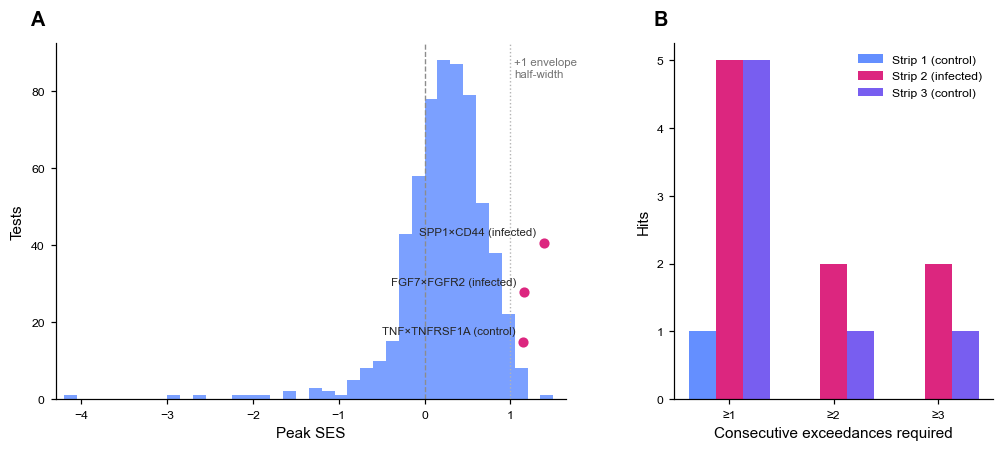

In [4]:
hits = d[d.max_consec >= 3].sort_values("max_consec", ascending=False)
print("strict hits (>=3 consecutive exceedances):", len(hits), "/", len(d))
print(hits[["ligand","receptor","strip","peak","max_consec"]].to_string(index=False))
print("\nPeak SES distribution: v1 mean %.3f median %.3f range %.2f..%.2f | v2 mean %.3f" % (
      v1.apply(peak_ses,axis=1).mean(), v1.apply(peak_ses,axis=1).median(),
      v1.apply(peak_ses,axis=1).min(), v1.apply(peak_ses,axis=1).max(), v2.apply(peak_ses,axis=1).mean()))
v1p = (v1.ligand + " x " + v1.receptor)
print("per-strip mean Peak SES (v1):", d[d.pair.isin(v1p)].groupby("strip").peak.mean().round(2).to_dict())

# sensitivity of the binary test to the consecutive-exceedance threshold (full screen, 605 unique tests)
u = d.drop_duplicates(["pair", "strip"])
strips = ["strip_1", "strip_2", "strip_3"]
sens = {k: {st: int(((u.max_consec >= k) & (u.strip == st)).sum()) for st in strips} for k in (1, 2, 3)}
for k in (1, 2, 3):
    print("n_consec >= %d: %d hits  (per strip %s)" % (k, sum(sens[k].values()), [sens[k][st] for st in strips]))
COND = {"strip_1": "control", "strip_2": "infected", "strip_3": "control"}

# --- R3 figure: (A) peak-SES distribution with strict hits flagged; (B) threshold collapse by strip ---
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.6, 1.0], "wspace": 0.26})
axA.hist(u.peak, bins=np.arange(-4.2, 1.65, 0.15), color=IBM["blue"], alpha=0.85)
axA.axvline(0, color="0.55", ls="--", lw=0.9); axA.axvline(1, color="0.7", ls=":", lw=0.9)
ymax = axA.get_ylim()[1]
axA.text(1.04, ymax * 0.96, "+1 envelope\nhalf-width", fontsize=7.5, color=MUTED, va="top")
sh = u[u.max_consec >= 3].sort_values("peak")
for j, (_, r) in enumerate(sh.iterrows()):
    y = ymax * (0.16 + 0.14 * j)
    axA.scatter(r.peak, y, s=32, c=IBM["magenta"], zorder=5)
    axA.annotate("%s\u00d7%s (%s)" % (r.ligand, r.receptor, COND[r.strip]), (r.peak, y),
                 xytext=(-5, 5), textcoords="offset points", fontsize=7.5, ha="right", color=INK)
axA.set_xlim(-4.3, 1.65); axA.set_xlabel("Peak SES", fontsize=10); axA.set_ylabel("Tests", fontsize=10)
axA.tick_params(labelsize=8); panel(axA, "A")
x = np.arange(3); wbar = 0.26
for i, st in enumerate(strips):
    axB.bar(x + (i - 1) * wbar, [sens[k][st] for k in (1, 2, 3)], width=wbar, color=STRIP[st], label=STRIP_LABEL[st])
axB.set_xticks(x); axB.set_xticklabels(["\u22651", "\u22652", "\u22653"], fontsize=10)
axB.set_xlabel("Consecutive exceedances required", fontsize=10); axB.set_ylabel("Hits", fontsize=10)
axB.tick_params(labelsize=8); axB.legend(frameon=False, fontsize=8); panel(axB, "B")
plt.tight_layout(); fig.savefig(FIG / "pub_r3_detection.png", dpi=300, bbox_inches="tight"); plt.show()

## Candidates: leading co-localisation signals in the infected strip  (Aim 1)
Descriptive ranking by Peak SES in the infected strip. This is selection-on-infected and NOT an
infection-specificity claim (the whole-screen infected mean is not elevated; see R3). The whole-screen
infected-minus-control boost is shown too, for the differential in R5, note it also surfaces control artifacts.

TOP 15 by Peak SES in the infected strip (candidates, Aim 1):
rank  pair                  peakSES  group          boost
  1  SPP1 x CD44           +1.39   G0_cellchatdb  +1.15
  2  FGF7 x FGFR2          +1.16   G8_paracrine   +0.42
  3  OAS1 x ISG15          +1.14   G7_infection   +0.45
  4  TNFSF9 x TNFRSF9      +1.07   G0_cellchatdb  +1.20
  5  CD40LG x CD40         +1.05   G0_cellchatdb  +0.75
  6  CCL2 x CCR2           +1.00   G8_paracrine   +0.64
  7  COL6A2 x CD44         +0.98   G0_cellchatdb  +0.53
  8  CXCL10 x CD3D         +0.97   G7_infection   +0.59
  9  CD68 x CD14           +0.96   G4_immune      +1.39
 10  FGF1 x FGFR2          +0.96   G0_cellchatdb  +0.77
 11  CD80 x CD28           +0.93   G0_cellchatdb  +0.10
 12  HLA-DRA x CD3D        +0.92   G7_infection   +0.74
 13  EFNB1 x EPHB3         +0.88   G0_cellchatdb  +0.25
 14  ICOSLG x CD28         +0.88   G0_cellchatdb  +0.72
 15  LAMA4 x CD44          +0.87   G0_cellchatdb  +0.47

TOP 10 by whole-screen infected-minus-c

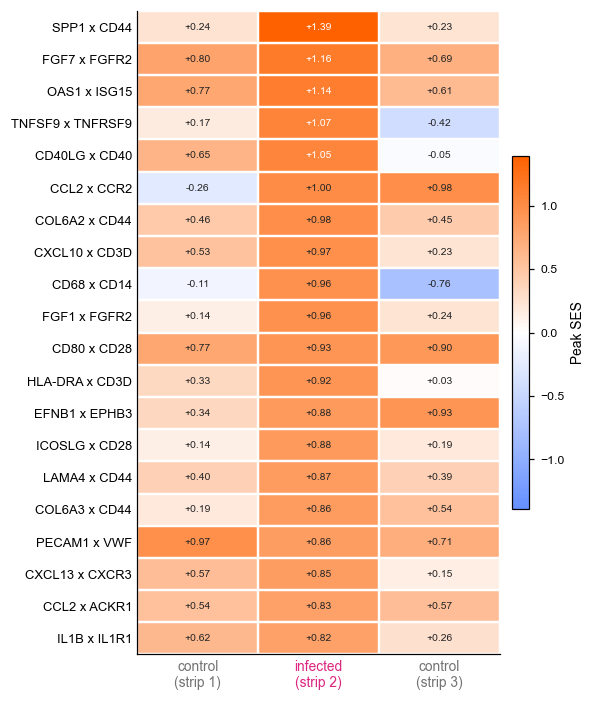

In [5]:
w = d.pivot_table("peak", ["ligand","receptor"], "strip", "max")
w["boost"] = w["strip_2"] - (w["strip_1"] + w["strip_3"]) / 2
s2 = d[d.strip == "strip_2"].dropna(subset=["peak"]).drop_duplicates("pair").sort_values("peak", ascending=False)
print("TOP 15 by Peak SES in the infected strip (candidates, Aim 1):")
print("rank  pair                  peakSES  group          boost")
for i, (_, r) in enumerate(s2.head(15).iterrows(), 1):
    b = w.loc[(r.ligand, r.receptor)].boost
    print(f"{i:>3}  {r.pair:21} {r.peak:+.2f}   {r.grp:14} {b:+.2f}")
print("\nTOP 10 by whole-screen infected-minus-control boost (Aim 3, exploratory):")
print("pair                  boost  infected  ctrl-mean")
for (a, b_), r in w.dropna(subset=["boost"]).sort_values("boost", ascending=False).head(10).iterrows():
    print(f"  {a+' x '+b_:20} {r.boost:+.2f}   {r.strip_2:+.2f}    {(r.strip_1+r.strip_3)/2:+.2f}")
print("\nwhole-screen boost: mean %.2f, median %.2f, %.0f%% positive (near-symmetric; no global shift)" % (
      w.boost.mean(), w.boost.median(), (w.boost > 0).mean() * 100))

# --- candidate SES heatmap: top-20 by infected-strip Peak SES, across the three strips ---
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
top = s2.head(20)
hm = d.pivot_table("peak", "pair", "strip", "max").loc[top.pair.values, ["strip_1", "strip_2", "strip_3"]]
cmap = LinearSegmentedColormap.from_list("div_ob", [IBM["blue"], "white", IBM["orange"]])  # high/hit = orange
vmax = float(np.nanmax(np.abs(hm.values)))
fig, ax = plt.subplots(figsize=(4.6, 7.6))
im = ax.imshow(hm.values, aspect="auto", cmap=cmap, norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax))
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["control\n(strip 1)", "infected\n(strip 2)", "control\n(strip 3)"], fontsize=9)
for t, col in zip(ax.get_xticklabels(), [MUTED, IBM["magenta"], MUTED]): t.set_color(col)
ax.set_yticks(range(len(hm))); ax.set_yticklabels(hm.index, fontsize=8.5)
for i in range(len(hm)):
    for j in range(3):
        v = hm.values[i, j]
        if not np.isnan(v): ax.text(j, i, "%+.2f" % v, ha="center", va="center", fontsize=6.8,
                                    color="white" if abs(v) > 0.72 * vmax else INK)
ax.set_xticks(np.arange(-0.5, 3, 1), minor=True); ax.set_yticks(np.arange(-0.5, len(hm), 1), minor=True)
ax.grid(which="minor", color="white", lw=1.6); ax.tick_params(which="minor", length=0); ax.tick_params(length=0)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03); cb.set_label("Peak SES", fontsize=9); cb.ax.tick_params(labelsize=8)
fig.savefig(FIG / "pub_candidates_heatmap.png", dpi=300, bbox_inches="tight"); plt.show()

## R4: Spatial scale of co-localisation  (Aim 2)
Radius at which Peak SES is reached, over the 605 unique tests. Scale is reported in pixels (the native,
uncalibrated unit); microns use the CosMx SMI nominal 0.12028 um/px only. Honest constraint: the scale does
not differ by gene class (Kruskal-Wallis), and most peaks fall beyond the 50 px cell-scale grid cutoff.

r_at_peak: median 130 px (~16 um), mean 144 px, range 5-250 px
peaks above the 50 px Cell-scale cutoff: 85%  (at or below: 15%)
median r_at_peak by class (px): {'other': 130, 'chemokine': 135, 'cytokine/TNF': 150, 'immune': 140, 'FGF/growth': 150, 'stromal/ECM': 160, 'epithelial': 130, 'interferon': 120}
Kruskal-Wallis r_at_peak vs gene class: p = 0.190  (no significant class-level scale structure)
hero SPP1 x CD44 (infected) peaks at r = 240 px (~29 um)


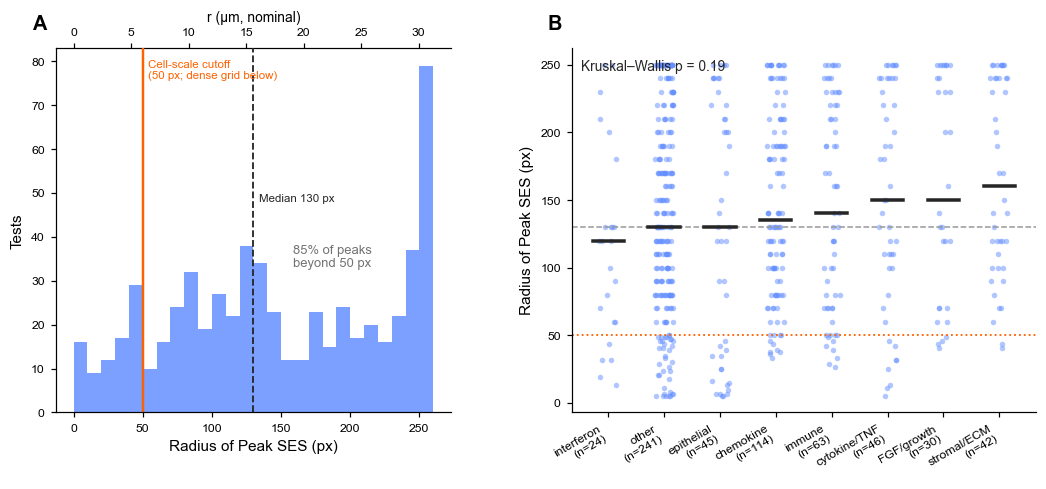

In [6]:
d["lclass"] = d.ligand.map(gclass)
u = d.drop_duplicates(["pair", "strip"]).copy()
classes = [c for c in u.lclass.unique() if (u.lclass == c).sum() > 5]
kw = kruskal(*[u.r_at_peak[u.lclass == c].values for c in classes])
med = float(np.median(u.r_at_peak))
print("r_at_peak: median %.0f px (~%.0f um), mean %.0f px, range %.0f-%.0f px" % (
      med, med * MPP, u.r_at_peak.mean(), u.r_at_peak.min(), u.r_at_peak.max()))
print("peaks above the %d px Cell-scale cutoff: %.0f%%  (at or below: %.0f%%)" % (
      R_CC, (u.r_at_peak > R_CC).mean() * 100, (u.r_at_peak <= R_CC).mean() * 100))
print("median r_at_peak by class (px):", {c: int(np.median(u.r_at_peak[u.lclass == c])) for c in classes})
print("Kruskal-Wallis r_at_peak vs gene class: p = %.3f  (no significant class-level scale structure)" % kw.pvalue)
h = get_row("SPP1", "CD44", "strip_2")
print("hero SPP1 x CD44 (infected) peaks at r = %d px (~%.0f um)" % (int(h.r_at_peak), h.r_at_peak * MPP))

# --- R4 figure: (A) r_at_peak distribution with the 50 px cutoff + median; (B) r_at_peak by gene class ---
order = sorted(classes, key=lambda c: np.median(u.r_at_peak[u.lclass == c]))
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 4.3), gridspec_kw={"width_ratios": [1.15, 1.35], "wspace": 0.28})
axA.hist(u.r_at_peak, bins=np.arange(0, 261, 10), color=IBM["blue"], alpha=0.85)
axA.axvline(R_CC, color=IBM["orange"], ls="-", lw=1.6); axA.axvline(med, color=INK, ls="--", lw=1.2)
yt = axA.get_ylim()[1]
axA.text(R_CC + 4, yt * 0.97, "Cell-scale cutoff\n(50 px; dense grid below)", fontsize=7.5, color=IBM["orange"], va="top")
axA.text(med + 4, yt * 0.60, "Median %d px" % med, fontsize=7.5, color=INK, va="top")
axA.annotate("%.0f%% of peaks\nbeyond 50 px" % ((u.r_at_peak > R_CC).mean() * 100), (0.60, 0.40),
             xycoords="axes fraction", fontsize=8.5, color=MUTED)
axA.set_xlabel("Radius of Peak SES (px)", fontsize=10); axA.set_ylabel("Tests", fontsize=10); axA.tick_params(labelsize=8)
sax = axA.secondary_xaxis("top", functions=(lambda x: x * MPP, lambda x: x / MPP))
sax.set_xlabel("r (\u00b5m, nominal)", fontsize=9); sax.tick_params(labelsize=8)
panel(axA, "A")
rng = np.random.default_rng(0)
for i, c in enumerate(order):
    y = u.r_at_peak[u.lclass == c].values
    axB.scatter(i + rng.uniform(-0.16, 0.16, len(y)), y, s=13, c=IBM["blue"], alpha=0.5, lw=0)
    axB.plot([i - 0.28, i + 0.28], [np.median(y)] * 2, color=INK, lw=2.3, zorder=4)
axB.axhline(med, color="0.6", ls="--", lw=1.0); axB.axhline(R_CC, color=IBM["orange"], ls=":", lw=1.2)
axB.set_xticks(range(len(order)))
axB.set_xticklabels(["%s\n(n=%d)" % (c, int((u.lclass == c).sum())) for c in order], fontsize=8, rotation=30, ha="right")
axB.set_ylabel("Radius of Peak SES (px)", fontsize=10); axB.tick_params(labelsize=8)
axB.text(0.02, 0.97, "Kruskal\u2013Wallis p = %.2f" % kw.pvalue, transform=axB.transAxes, fontsize=9, va="top", color=INK)
panel(axB, "B")
fig.savefig(FIG / "pub_r4_scale.png", dpi=300, bbox_inches="tight"); plt.show()

## R5: Infected vs control differential  (Aim 3): biological headline
Per-pair strip-2 boost = SES(strip 2) - mean(SES strips 1,3), within the pre-registered infection group (G7).
Mann-Whitney U: immune-communication + ISG pairs vs antiviral x epithelium.

immune-communication (n=6, mean boost +0.20):
    HLA-DRA x CD3D     +0.74
    CXCL10 x CD3D      +0.59
    HLA-DRA x CD68     +0.32
    IL6 x IL1B         +0.16
    ISG15 x CD68       +0.15
    CXCL8 x IL6        -0.74
ISG-ISG (n=4, mean boost +0.16):
    OAS1 x ISG15       +0.45
    IFIT1 x IFIT3      +0.24
    ISG15 x MX1        +0.01
    ISG15 x IFIT1      -0.07
antiviral x epithelium (n=3, mean boost -0.50):
    IFIT1 x KRT18      +0.04
    ISG15 x KRT8       -0.64
    MX1 x KRT5         -0.90

Mann-Whitney U (immune+ISG n=10 vs antiviral-epi n=3): U=26, one-sided p=0.038
G7 per-strip mean Peak SES: {'strip_1': 0.35, 'strip_2': 0.36, 'strip_3': 0.35}


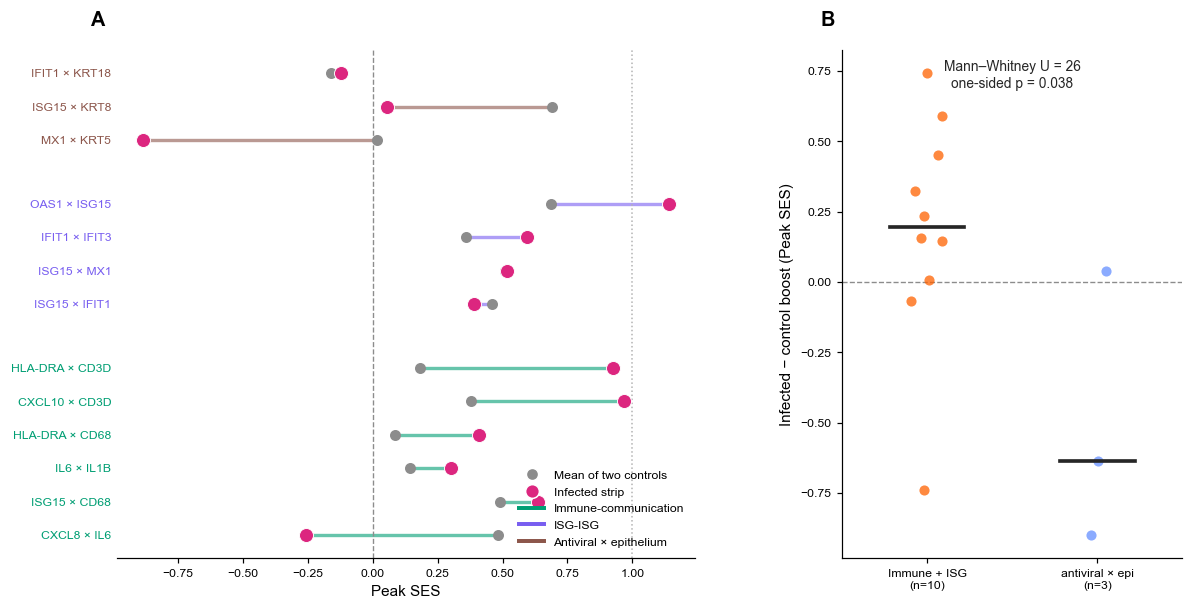

In [7]:
from matplotlib.lines import Line2D
w = d.pivot_table("peak", ["ligand","receptor"], "strip", "max")
w["boost"] = w["strip_2"] - (w["strip_1"] + w["strip_3"]) / 2
# families are a POST-HOC partition of the pre-registered G7 group by biological role
fam = {
 "immune-communication":   [("HLA-DRA","CD3D"),("CXCL10","CD3D"),("HLA-DRA","CD68"),("ISG15","CD68"),("IL6","IL1B"),("CXCL8","IL6")],
 "ISG-ISG":                [("OAS1","ISG15"),("IFIT1","IFIT3"),("ISG15","MX1"),("ISG15","IFIT1")],
 "antiviral x epithelium": [("IFIT1","KRT18"),("ISG15","KRT8"),("MX1","KRT5")],
}
FCOL = {"immune-communication": "#009E73", "ISG-ISG": IBM["purple"], "antiviral x epithelium": "#8C564B"}  # categorical families; blue/orange reserved for sign
def bval(a, b):
    return float(w.loc[(a, b)].boost) if (a, b) in w.index and not np.isnan(w.loc[(a, b)].boost) else None
vals = {k: [(f"{a} x {b}", bval(a, b)) for a, b in v if bval(a, b) is not None] for k, v in fam.items()}
for k, v in vals.items():
    print(f"{k} (n={len(v)}, mean boost {np.mean([x[1] for x in v]):+.2f}):")
    for nm, bv in sorted(v, key=lambda z: -z[1]): print(f"    {nm:18} {bv:+.2f}")
pos = [x[1] for x in vals["immune-communication"] + vals["ISG-ISG"]]; neg = [x[1] for x in vals["antiviral x epithelium"]]
U, p = mannwhitneyu(pos, neg, alternative="greater")
print(f"\nMann-Whitney U (immune+ISG n={len(pos)} vs antiviral-epi n={len(neg)}): U={U:.0f}, one-sided p={p:.3f}")
g7set = {frozenset(pr) for pr in GROUPS["G7_infection"]}
g7rows = d[[frozenset((a, b)) in g7set for a, b in zip(d.ligand, d.receptor)]]
print("G7 per-strip mean Peak SES:", g7rows.groupby("strip").peak.mean().round(2).to_dict())

# --- R5 figure: (A) per-pair dumbbell grouped by family; (B) boost by MWU group ---
fig = plt.figure(figsize=(12.5, 6.0))
gs = fig.add_gridspec(1, 2, width_ratios=[1.7, 1.0], wspace=0.32)
axA = fig.add_subplot(gs[0, 0]); axB = fig.add_subplot(gs[0, 1])
ypos, ylab, ycol = [], [], []
y = 0
for fname in ["immune-communication", "ISG-ISG", "antiviral x epithelium"]:
    prs = sorted([(f"{a} \u00d7 {b}", w.loc[(a, b)]) for a, b in fam[fname] if bval(a, b) is not None],
                 key=lambda z: z[1].boost)
    for nm, r in prs:
        c = (r.strip_1 + r.strip_3) / 2
        axA.plot([c, r.strip_2], [y, y], color=FCOL[fname], lw=2.2, alpha=0.6, zorder=1)
        axA.scatter(c, y, s=52, c="0.55", zorder=2, lw=0)
        axA.scatter(r.strip_2, y, s=84, c=IBM["magenta"], zorder=3, edgecolors="white", linewidths=0.6)
        ypos.append(y); ylab.append(nm); ycol.append(FCOL[fname]); y += 1
    y += 0.9
axA.axvline(0, color="0.55", ls="--", lw=0.9); axA.axvline(1, color="0.7", ls=":", lw=1.0)
axA.set_yticks(ypos); axA.set_yticklabels(ylab, fontsize=9)
for t, col in zip(axA.get_yticklabels(), ycol): t.set_color(col)
axA.tick_params(axis="y", length=0); axA.spines["left"].set_visible(False)
axA.set_xlabel("Peak SES", fontsize=10); axA.tick_params(labelsize=8)
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor="0.55", markersize=8, label="Mean of two controls"),
           Line2D([0], [0], marker="o", color="w", markerfacecolor=IBM["magenta"], markersize=9, label="Infected strip")]
handles += [Line2D([0], [0], color=FCOL[f], lw=2.6, label={"immune-communication":"Immune-communication","ISG-ISG":"ISG-ISG","antiviral x epithelium":"Antiviral × epithelium"}[f]) for f in FCOL]
axA.legend(handles=handles, frameon=False, fontsize=8, loc="lower right"); panel(axA, "A")
rng = np.random.default_rng(1)
groups = [("Immune + ISG\n(n=%d)" % len(pos), pos, POS), ("antiviral \u00d7 epi\n(n=%d)" % len(neg), neg, NEG)]
for i, (lab, vv, col) in enumerate(groups):
    axB.scatter(i + rng.uniform(-0.10, 0.10, len(vv)), vv, s=44, c=col, alpha=0.75, lw=0, zorder=3)
    axB.plot([i - 0.22, i + 0.22], [np.median(vv)] * 2, color=INK, lw=2.4, zorder=4)
axB.axhline(0, color="0.55", ls="--", lw=0.9)
axB.set_xticks([0, 1]); axB.set_xticklabels([g[0] for g in groups], fontsize=9); axB.set_xlim(-0.5, 1.5)
axB.set_ylabel("Infected \u2212 control boost (Peak SES)", fontsize=10); axB.tick_params(labelsize=8)
axB.text(0.5, 0.98, "Mann\u2013Whitney U = %d\none-sided p = %.3f" % (U, p), transform=axB.transAxes,
         ha="center", va="top", fontsize=9, color=INK)
panel(axB, "B")
fig.savefig(FIG / "pub_infection_g7.png", dpi=300, bbox_inches="tight"); plt.show()

## R6: The strict hit: SPP1 x CD44  (Aim 1/3)
The one pair passing the strict envelope criterion. (A) real SPP1 and CD44 transcripts in the infected strip,
zoomed on their densest co-localised region (grey = all retained transcripts; dashed circle = the 240 px
co-localisation radius; inset = whole-strip locator). (B) SES(r) across the three strips: the infected strip
exceeds the +1 envelope while both controls stay within it. Absolute positions only; candidate co-localisation.

infected strip: SPP1 94, CD44 129; SPP1 with a CD44 within 240 px: 75/94 (80%), median NN 113 px
SPP1 x CD44 exceedances per strip: {'strip_1': 0, 'strip_2': 10, 'strip_3': 0}


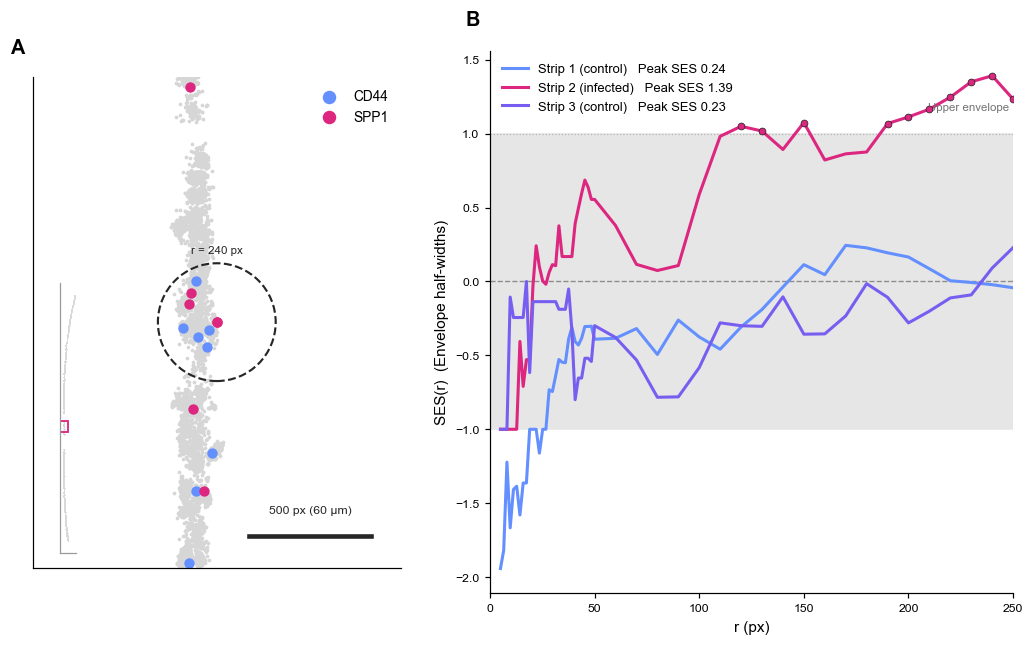

In [8]:
from matplotlib.patches import Circle, Rectangle
from scipy.spatial import cKDTree
tx = pd.read_parquet(ROOT / "data" / "processed" / "s1_all_strips_cleaned.parquet")
tx = tx[~(tx.is_noise | tx.is_small_cluster | tx.manually_excluded)]
s2 = tx[tx.strip == "strip_2"]
XY = s2[["x_rot_px", "y_rot_px"]].values
spp1 = s2[s2.target == "SPP1"][["x_rot_px", "y_rot_px"]].values
cd44 = s2[s2.target == "CD44"][["x_rot_px", "y_rot_px"]].values
tcd = cKDTree(cd44); nn, _ = tcd.query(spp1, k=1)
print("infected strip: SPP1 %d, CD44 %d; SPP1 with a CD44 within 240 px: %d/%d (%.0f%%), median NN %.0f px" % (
      len(spp1), len(cd44), (nn < 240).sum(), len(spp1), 100 * (nn < 240).mean(), np.median(nn)))
ncd = np.array([len(tcd.query_ball_point(pt, 240)) for pt in spp1])
cx, cy = spp1[int(np.argmax(ncd))]      # densest co-localised SPP1 (algorithmic, not hand-picked)
HWX, HWY = 750, 1000; x0, x1 = cx - HWX, cx + HWX; y0, y1 = cy - HWY, cy + HWY   # cell-neighbourhood window

fig = plt.figure(figsize=(11.5, 6.4))
gs = fig.add_gridspec(1, 2, width_ratios=[0.95, 1.35], wspace=0.2)
axA = fig.add_subplot(gs[0, 0]); axB = fig.add_subplot(gs[0, 1])

m = (XY[:, 0] >= x0) & (XY[:, 0] <= x1) & (XY[:, 1] >= y0) & (XY[:, 1] <= y1)
axA.scatter(XY[m, 0], XY[m, 1], s=6, c="0.84", lw=0, rasterized=True)
def _win(P): return P[(P[:, 0] >= x0) & (P[:, 0] <= x1) & (P[:, 1] >= y0) & (P[:, 1] <= y1)]
cp, sp = _win(cd44), _win(spp1)
axA.scatter(cp[:, 0], cp[:, 1], s=46, c=IBM["blue"], lw=0, label="CD44")
axA.scatter(sp[:, 0], sp[:, 1], s=46, c=IBM["magenta"], lw=0, label="SPP1")
axA.add_patch(Circle((cx, cy), 240, fill=False, ec=INK, lw=1.4, ls="--"))
axA.text(cx, cy + 270, "r = 240 px", fontsize=7.5, ha="center", va="bottom", color=INK)
axA.set_aspect("equal"); axA.set_xlim(x0, x1); axA.set_ylim(y0, y1); axA.set_xticks([]); axA.set_yticks([])
axA.plot([x1 - 620, x1 - 120], [y0 + 130, y0 + 130], color=INK, lw=3)
axA.text(x1 - 370, y0 + 220, "500 px (60 \u00b5m)", fontsize=8, ha="center", color=INK)
axA.legend(frameon=False, fontsize=9, loc="upper right", markerscale=1.3)
axl = axA.inset_axes([0.03, 0.03, 0.13, 0.55])
axl.scatter(XY[:, 0], XY[:, 1], s=0.3, c="0.85", lw=0, rasterized=True)
axl.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=IBM["magenta"], lw=1.2))
axl.set_aspect("equal"); axl.set_xticks([]); axl.set_yticks([])
for sp_ in axl.spines.values(): sp_.set_edgecolor("0.6")
panel(axA, "A")

axB.axhspan(-1, 1, color=BAND, zorder=0); axB.axhline(0, color="0.55", ls="--", lw=0.9); axB.axhline(1, color="0.7", ls=":", lw=0.8)
for st in ["strip_1", "strip_2", "strip_3"]:
    row = get_row("SPP1", "CD44", st); cc = ses_curve(row)
    axB.plot(R, cc, color=STRIP[st], lw=2.0, label="%s   Peak SES %.2f" % (STRIP_LABEL[st], peak_ses(row)))
    exc = np.array(row.l_obs, float) > np.array(row.l_hi, float)
    if exc.any(): axB.scatter(R[exc], cc[exc], s=20, color=STRIP[st], edgecolors=INK, linewidths=0.5, zorder=5)
axB.set_xlabel("r (px)", fontsize=10); axB.set_ylabel("SES(r)  (Envelope half-widths)", fontsize=10)
axB.set_xlim(0, 250); axB.tick_params(labelsize=8)
axB.text(248, 1.16, "Upper envelope", fontsize=7.5, ha="right", color=MUTED)
axB.legend(frameon=False, fontsize=8.5, loc="upper left"); panel(axB, "B")
print("SPP1 x CD44 exceedances per strip:", {st: n_exceed(get_row("SPP1","CD44",st))[1] for st in ["strip_1","strip_2","strip_3"]})
fig.savefig(FIG / "pub_hero_profile.png", dpi=300, bbox_inches="tight"); plt.show()

## R7: Per-strip networks and profile embedding  (Aim 1): honest negative
At the strict criterion the per-strip networks reduce to a single edge (SPP1 x CD44, infected). A UMAP of the
50-dim L(r) profiles, coloured by pre-registered group, shows no cluster structure (ANOSIM R near 0): the screen
did not recover communication-network structure, and stating that plainly is a valid result.

ANOSIM R: group = 0.031, strip = 0.275  (0 = no separation, ~1 = clean clusters)
strict network edges (>=3 consecutive upper-envelope exceedances): 1
source target   strip    weight  ses_peak  r_at_peak
  SPP1   CD44 strip_2 13.977749  1.391194      240.0


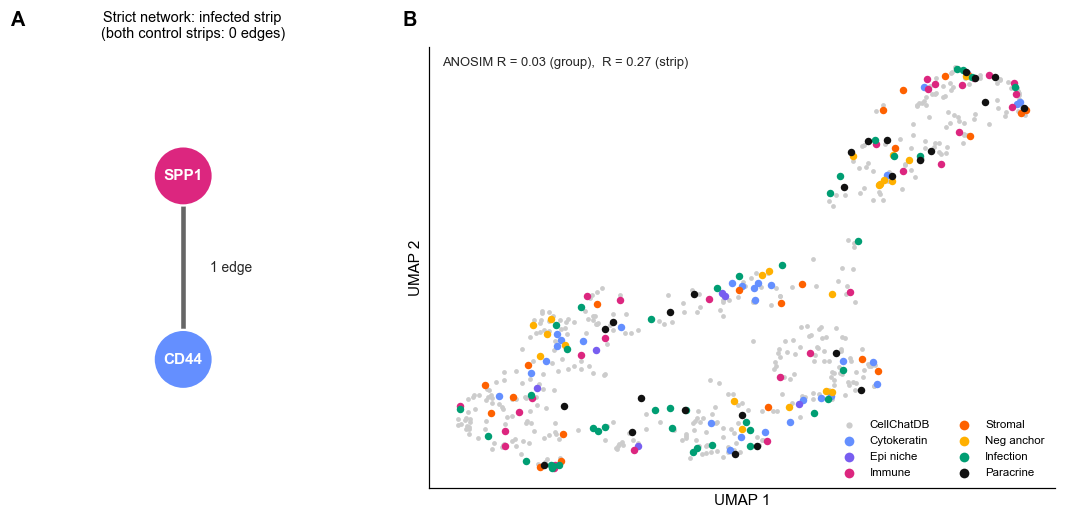

In [9]:
from sklearn.preprocessing import StandardScaler
import umap
from scipy.spatial.distance import pdist
uu = d.drop_duplicates(["pair", "strip"]).reset_index(drop=True)
L = np.vstack([np.array(r.l_obs, float) for _, r in uu.iterrows()])
Z = StandardScaler().fit_transform(L)
emb = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(Z)
Dv = pd.Series(pdist(Z, "euclidean")).rank().values
def anosim_R(labels):
    N = len(labels); iu = np.triu_indices(N, 1); same = labels[iu[0]] == labels[iu[1]]
    return (Dv[~same].mean() - Dv[same].mean()) / (N * (N - 1) / 4)
Rg, Rs = anosim_R(uu.grp.values), anosim_R(uu.strip.values)
print("ANOSIM R: group = %.3f, strip = %.3f  (0 = no separation, ~1 = clean clusters)" % (Rg, Rs))
edges = pd.read_csv(ROOT / "results" / "12_edge_summary.csv")
print("strict network edges (>=3 consecutive upper-envelope exceedances):", len(edges))
print(edges.to_string(index=False))

glab = {"G0_cellchatdb":"CellChatDB","G1_cytokeratin":"Cytokeratin","G3_epi_niche":"Epi niche","G4_immune":"Immune","G5_stromal":"Stromal","G6_neg_anchor":"Neg anchor","G7_infection":"Infection","G8_paracrine":"Paracrine"}
GCOL = {"G0_cellchatdb":"0.80","G1_cytokeratin":IBM["blue"],"G3_epi_niche":IBM["purple"],"G4_immune":IBM["magenta"],"G5_stromal":IBM["orange"],"G6_neg_anchor":IBM["yellow"],"G7_infection":"#009E73","G8_paracrine":"#111111"}

fig = plt.figure(figsize=(12, 5.2))
gs = fig.add_gridspec(1, 2, width_ratios=[0.72, 1.4], wspace=0.16)
axA = fig.add_subplot(gs[0, 0]); axB = fig.add_subplot(gs[0, 1])
axA.plot([0, 0], [1, -1], color="0.4", lw=3, zorder=2)
axA.scatter([0, 0], [1, -1], s=1500, c=[IBM["magenta"], IBM["blue"]], zorder=3, edgecolors="white", linewidths=1.5)
axA.text(0, 1, "SPP1", fontsize=10, ha="center", va="center", color="white", fontweight="bold")
axA.text(0, -1, "CD44", fontsize=10, ha="center", va="center", color="white", fontweight="bold")
axA.text(0.14, 0, "1 edge", fontsize=9, va="center", color=INK)
axA.set_xlim(-0.8, 0.9); axA.set_ylim(-2.4, 2.4); axA.axis("off")
axA.set_title("Strict network: infected strip\n(both control strips: 0 edges)", fontsize=9.5)
panel(axA, "A")
g0 = uu.grp == "G0_cellchatdb"
axB.scatter(emb[g0, 0], emb[g0, 1], s=10, c=GCOL["G0_cellchatdb"], lw=0, label="CellChatDB")
for g in ["G1_cytokeratin","G3_epi_niche","G4_immune","G5_stromal","G6_neg_anchor","G7_infection","G8_paracrine"]:
    mk = uu.grp == g
    axB.scatter(emb[mk, 0], emb[mk, 1], s=24, c=GCOL[g], lw=0, label=glab[g])
axB.set_xlabel("UMAP 1", fontsize=10); axB.set_ylabel("UMAP 2", fontsize=10); axB.set_xticks([]); axB.set_yticks([])
axB.text(0.02, 0.98, "ANOSIM R = %.2f (group),  R = %.2f (strip)" % (Rg, Rs), transform=axB.transAxes, va="top", fontsize=8.5, color=INK)
axB.legend(frameon=False, fontsize=7.5, loc="lower right", ncol=2, markerscale=1.3)
panel(axB, "B")
fig.savefig(FIG / "pub_r7_networks.png", dpi=300, bbox_inches="tight"); plt.show()

## Summary: the largest infected-vs-control gains  (positive closer)
Top 20 pairs by infected-minus-control boost, restricted to pairs that are themselves prominent in the infected
strip (infected Peak SES >= 0.5) so the gain is a genuine infected elevation, not a control artifact. Orange =
infected (positive), grey = mean of the two controls.

top-20 infection boosts (infected Peak SES >= 0.5):
  CD68 x CD14: boost +1.39 (infected +0.96, control -0.43)
  TNFSF9 x TNFRSF9: boost +1.20 (infected +1.07, control -0.13)
  SPP1 x CD44: boost +1.15 (infected +1.39, control +0.24)
  IGF2 x IGF1R: boost +0.95 (infected +0.75, control -0.20)
  FGF1 x FGFR2: boost +0.77 (infected +0.96, control +0.19)
  CD40LG x CD40: boost +0.75 (infected +1.05, control +0.30)
  KRT14 x KRT17: boost +0.75 (infected +0.69, control -0.05)
  HLA-DRA x CD3D: boost +0.74 (infected +0.92, control +0.18)
  IL1A x IL1R2: boost +0.73 (infected +0.81, control +0.08)
  ICOSLG x CD28: boost +0.72 (infected +0.88, control +0.17)
  COL6A1 x CD44: boost +0.70 (infected +0.63, control -0.07)
  IL16 x CD4: boost +0.68 (infected +0.66, control -0.02)
  CD3D x CD3E: boost +0.66 (infected +0.81, control +0.16)
  CCL2 x CCR2: boost +0.64 (infected +1.00, control +0.36)
  HGF x MET: boost +0.61 (infected +0.53, control -0.08)
  PDGFC x PDGFRA: boost +0.60 (infected +0.79, 

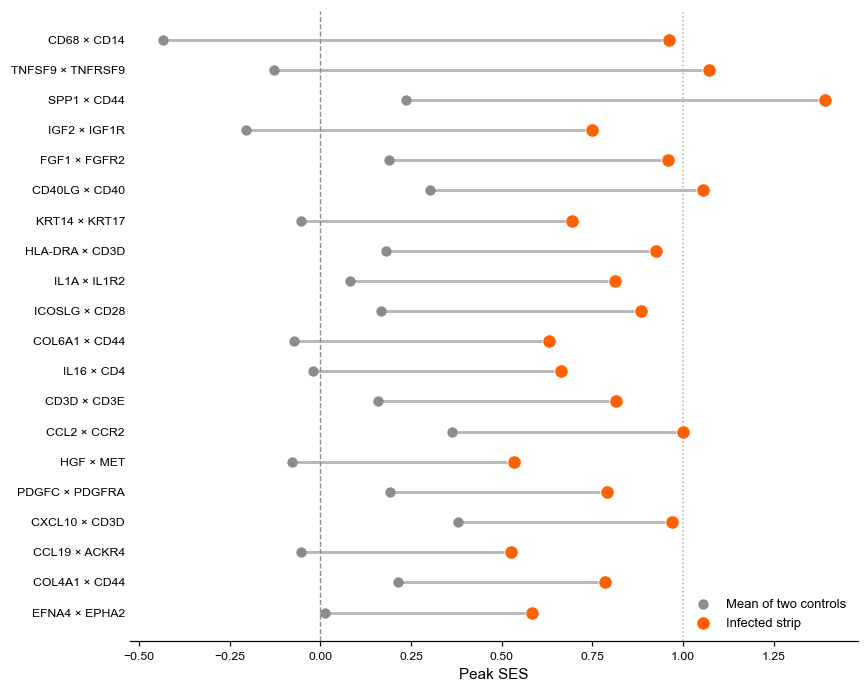

In [10]:
w = d.pivot_table("peak", ["ligand", "receptor"], "strip", "max")
w["ctrl"] = (w.strip_1 + w.strip_3) / 2
w["boost"] = w.strip_2 - w.ctrl
sel = w.dropna(subset=["boost"])
sel = sel[sel.strip_2 >= 0.5].sort_values("boost", ascending=False).head(20)
print("top-20 infection boosts (infected Peak SES >= 0.5):")
for (a, b), r in sel.iterrows(): print(f"  {a} x {b}: boost {r.boost:+.2f} (infected {r.strip_2:+.2f}, control {r.ctrl:+.2f})")

fig, ax = plt.subplots(figsize=(8, 6.4))
rows = list(sel.iterrows())[::-1]   # largest boost at the top
for i, ((a, b), r) in enumerate(rows):
    ax.plot([r.ctrl, r.strip_2], [i, i], color="0.72", lw=1.9, zorder=1)
    ax.scatter(r.ctrl, i, s=46, c="0.55", zorder=2, lw=0, label="Mean of two controls" if i == 0 else None)
    ax.scatter(r.strip_2, i, s=78, c=POS, zorder=3, edgecolors="white", linewidths=0.6, label="Infected strip" if i == 0 else None)
ax.axvline(0, color="0.55", ls="--", lw=0.9); ax.axvline(1, color="0.7", ls=":", lw=1.0)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([f"{a} \u00d7 {b}" for (a, b), r in rows], fontsize=8.5)
ax.set_xlabel("Peak SES", fontsize=10); ax.tick_params(labelsize=8); ax.tick_params(axis="y", length=0)
ax.spines["left"].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
plt.tight_layout(); fig.savefig(FIG / "pub_boost_dumbbell.png", dpi=300, bbox_inches="tight"); plt.show()